In [4]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *
from lightgbm import LGBMClassifier

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [5]:
from dcr import *  

data = data.query('time <=40').copy()  
_, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(data,  depvar='default_time', splitvar='time', threshold=26)

In [6]:
print('Shape train data:', X_train_scaled.shape)  
print('Shape test data:', X_test_scaled.shape)  
print('Default rate train data:', np.mean(y_train).round(4))  
print('Default rate test data:', np.mean(y_test).round(4))

Shape train data: (12702, 11)
Shape test data: (27368, 11)
Default rate train data: 0.0104
Default rate test data: 0.0355


In [7]:
lr_bag = LogisticRegression(penalty='l1', fit_intercept=True, C=0.1, solver='saga', tol =1e-15, max_iter=1000) 
model_lr_bag=BaggingClassifier(lr_bag, n_estimators=20, max_samples=0.8, max_features=1.0,  bootstrap=True, warm_start=False, n_jobs=2, oob_score=True, random_state=0, verbose=2)  
model_lr_bag.fit(X_train_scaled, y_train)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    4.7s finished


BaggingClassifier(estimator=LogisticRegression(C=0.1, max_iter=1000,
                                               penalty='l1', solver='saga',
                                               tol=1e-15),
                  max_samples=0.8, n_estimators=20, n_jobs=2, oob_score=True,
                  random_state=0, verbose=2)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


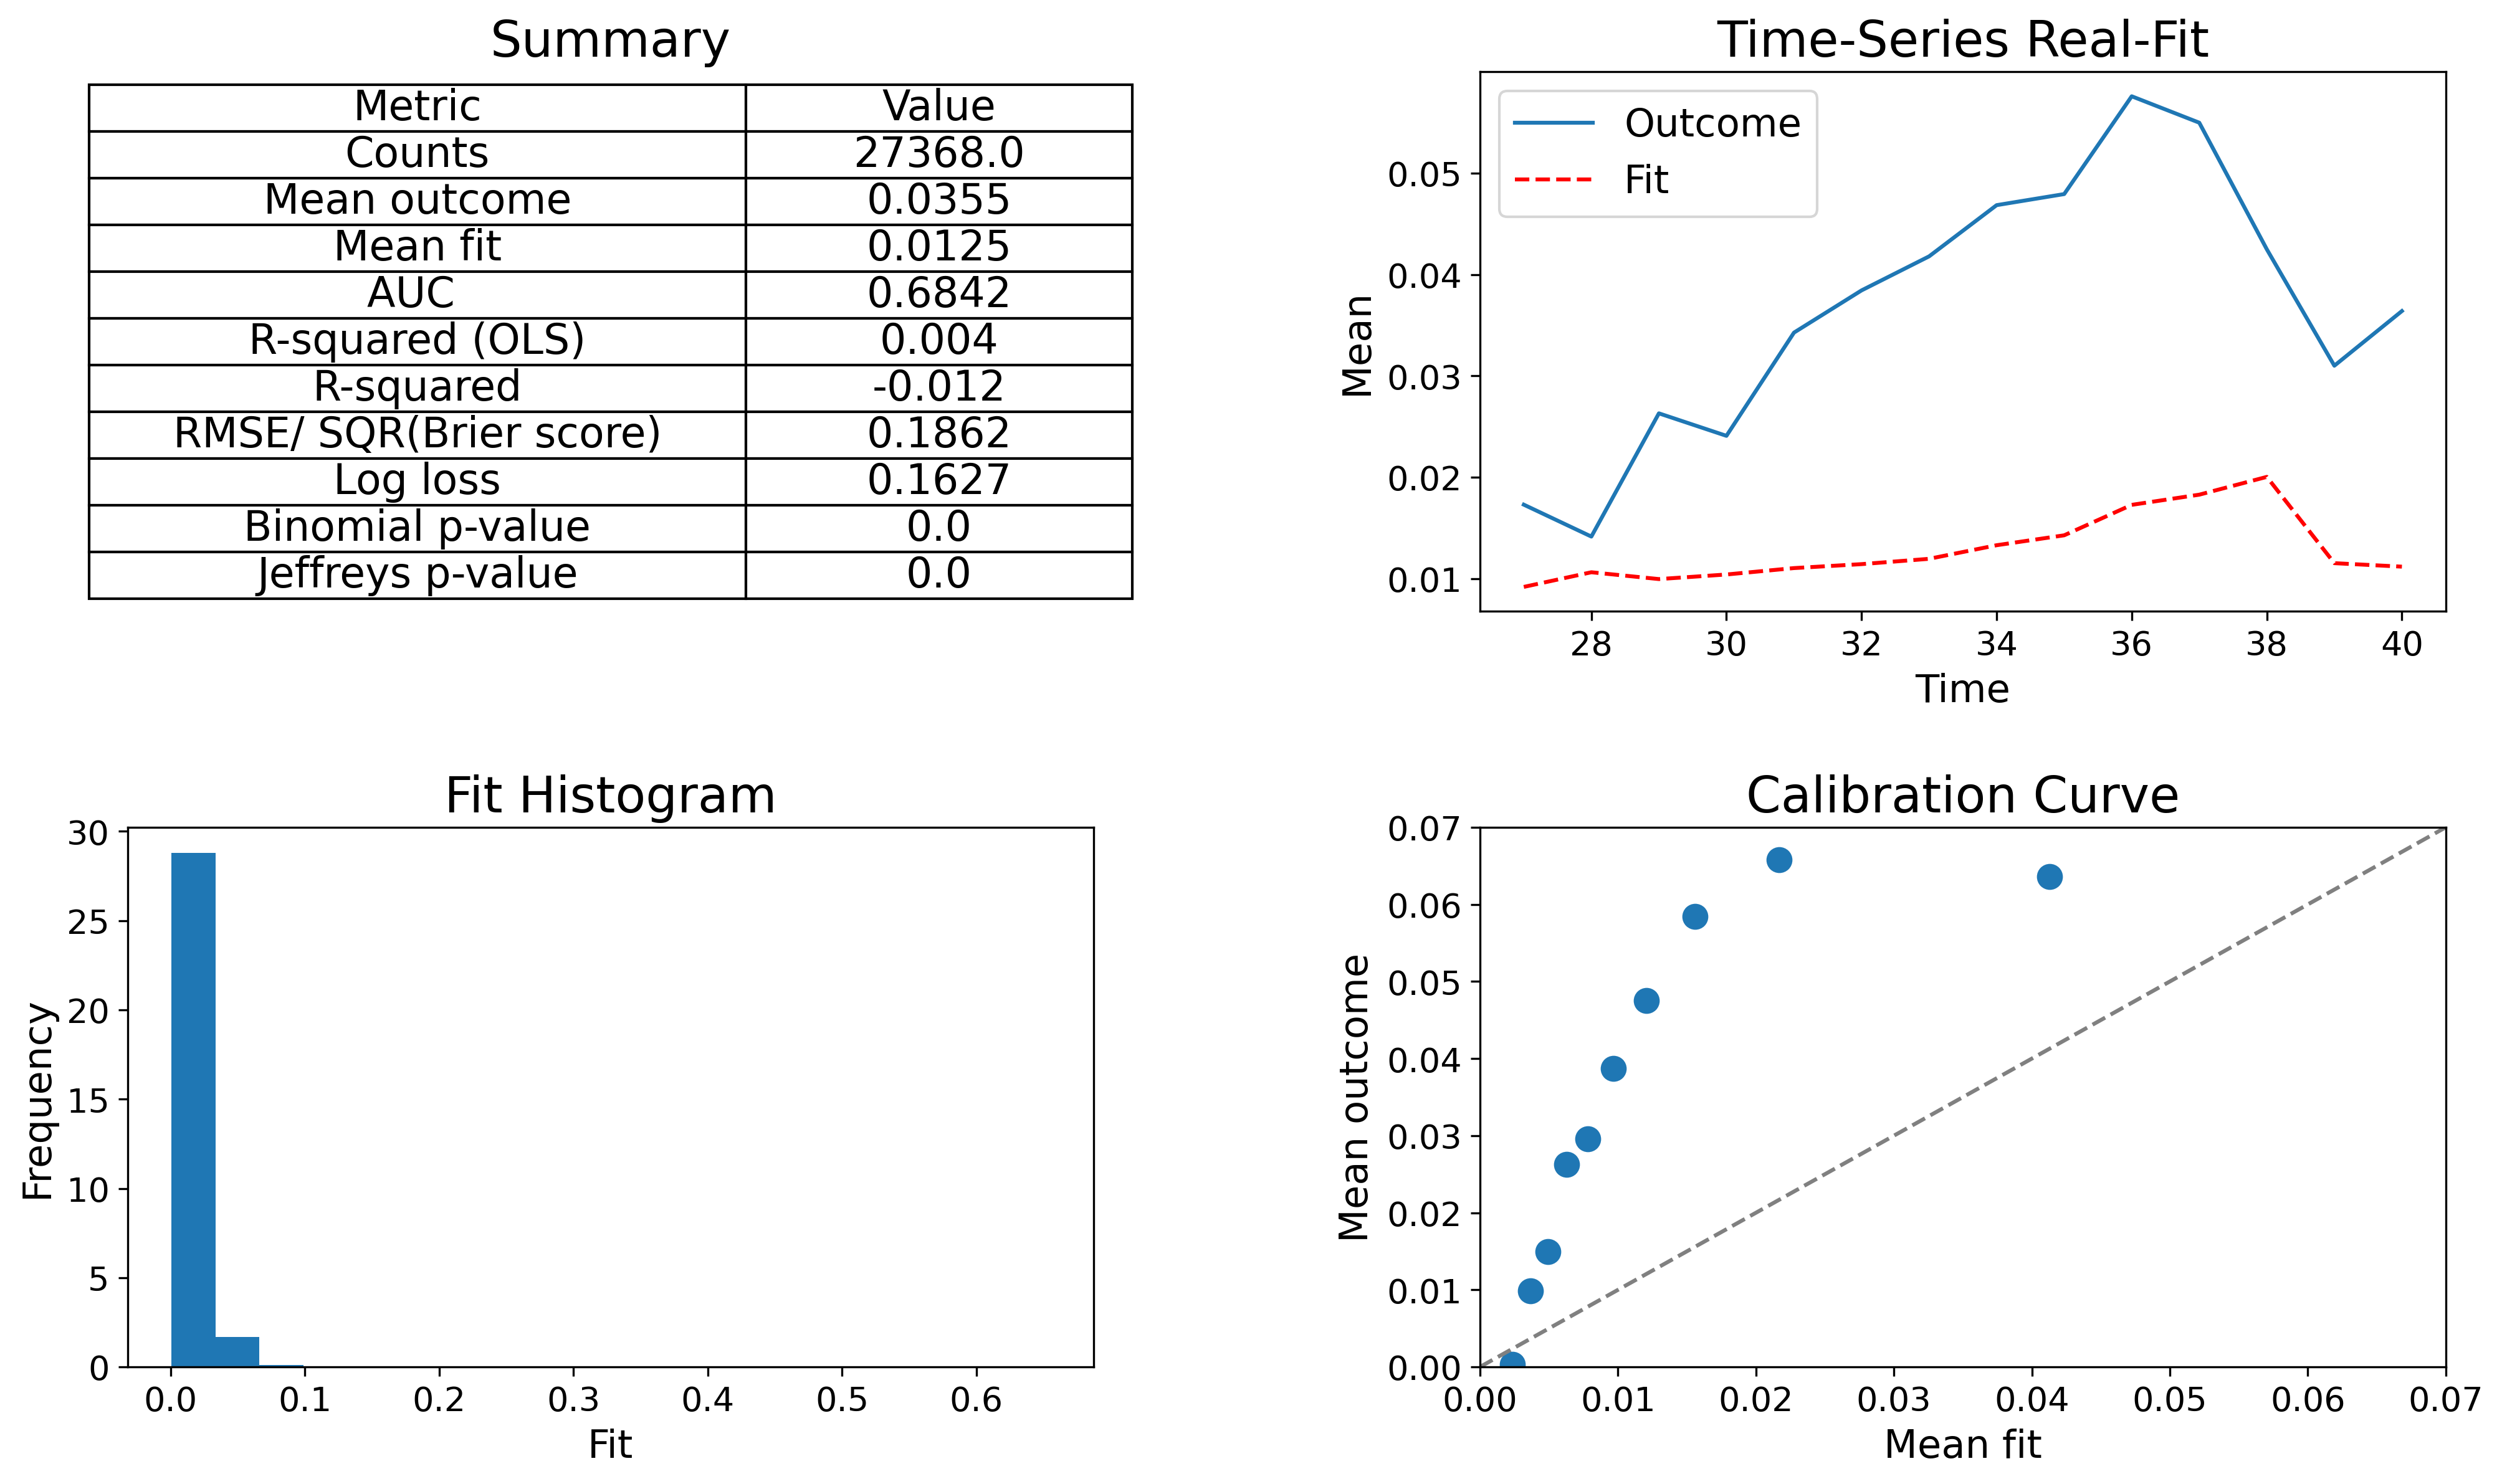

In [8]:
predictions_test = model_lr_bag.predict_proba(X_test_scaled)[:,1].T 
validation(predictions_test, y_test, data_test['time'].values)  
AUC_bag = roc_auc_score(y_test, predictions_test).round(4)
sqrt_brier_bag = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)

In [9]:
lr_boost = LogisticRegression(penalty='l2', fit_intercept=True, C=10, solver='lbfgs', tol=1e-15, max_iter=2000)  
model_lr_boost=AdaBoostClassifier(lr_boost, n_estimators=50, learning_rate=0.01,  random_state=2)  
model_lr_boost.fit(X_train_scaled, y_train)

AdaBoostClassifier(estimator=LogisticRegression(C=10, max_iter=2000, tol=1e-15),
                   learning_rate=0.01, random_state=2)

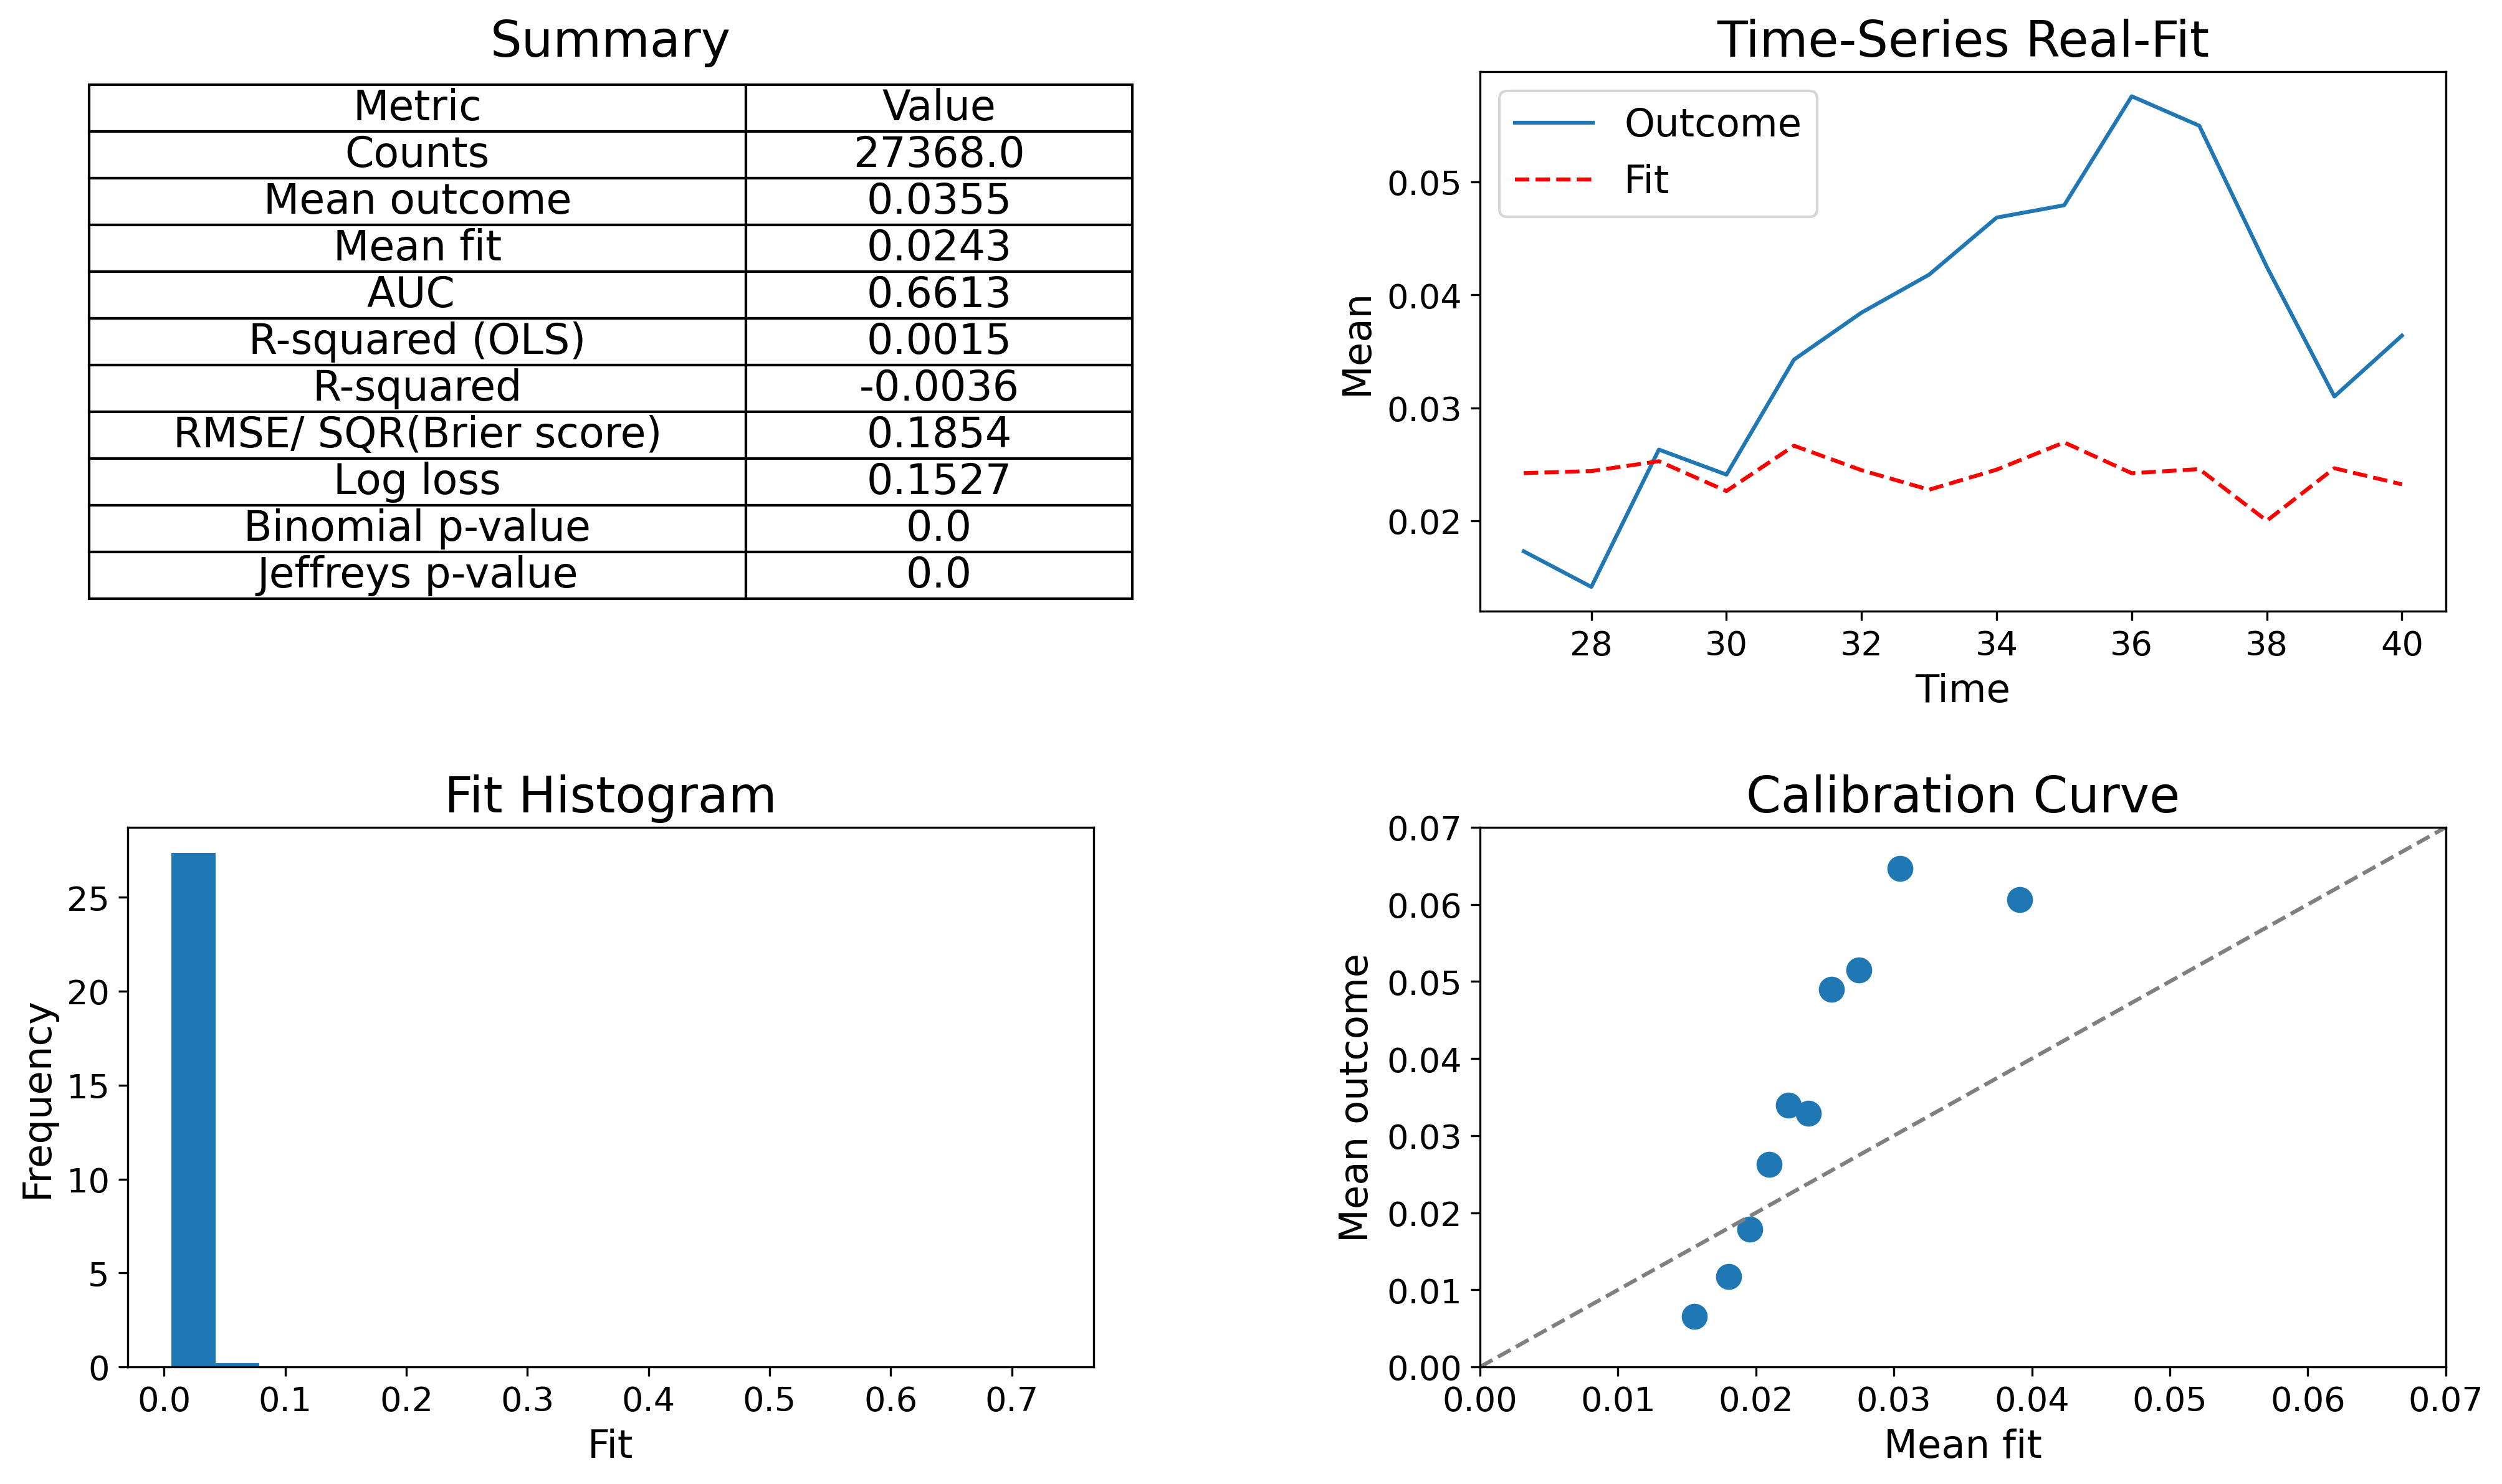

In [10]:
predictions_test = model_lr_boost.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_adareg = roc_auc_score(y_test, predictions_test).round(4)
sqrt_brier_adareg = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [11]:
model_rfc = RandomForestClassifier(random_state=0, max_depth=5, warm_start=True,  n_estimators=100)  
model_rfc.fit(X_train_scaled, y_train)  
print(model_rfc.feature_importances_.round(decimals=4)) 

[0.2084 0.1828 0.2013 0.2226 0.0353 0.0291 0.0248 0.0293 0.0251 0.039
 0.0024]


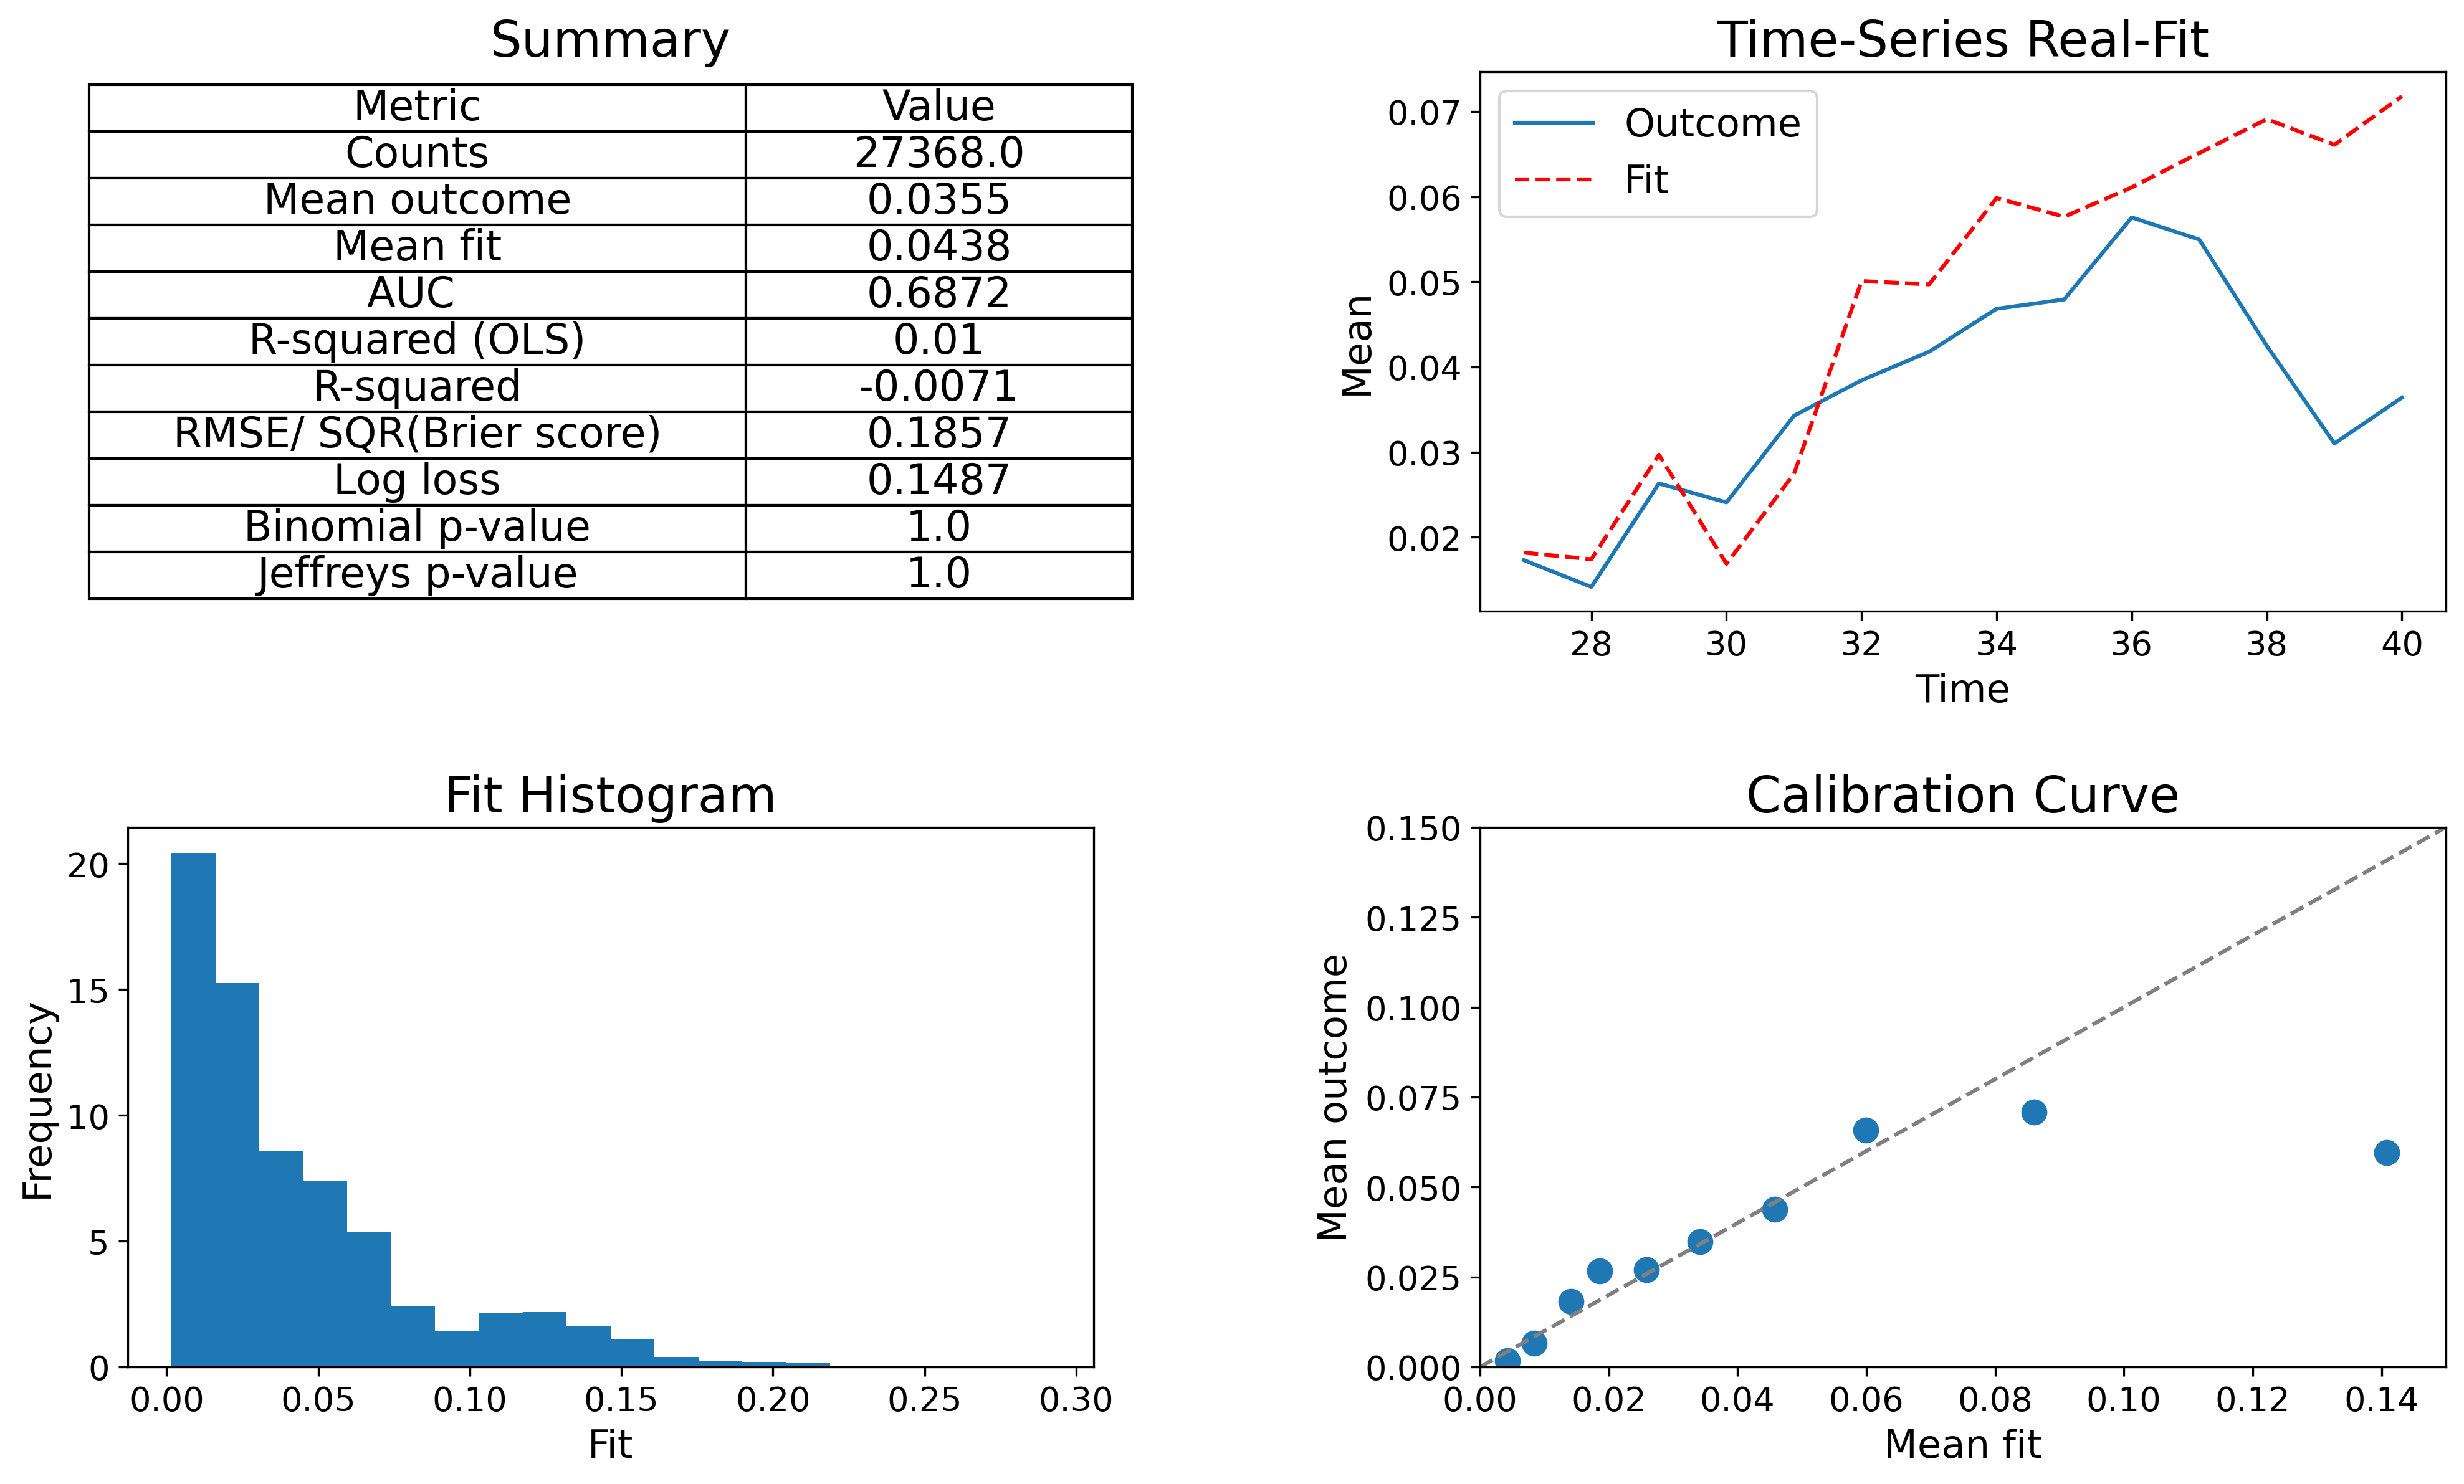

In [12]:
predictions_test = model_rfc.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_rf = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_rf = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)  

In [13]:
params_rfc = {'n_estimators': sp_randint(1, 500), 'max_depth': [2, 3, 4, 5, 10, None], 'max_features': sp_randint(1, 10), 'min_samples_split': sp_randint(2, 11)} 
model_rfc = RandomForestClassifier() 
rs_rfc = RandomizedSearchCV(model_rfc, params_rfc, verbose=1, n_iter=50, n_jobs=2, cv=5,  scoring='roc_auc') 
rs_rfc.fit(X_train_scaled, y_train)  
print(rs_rfc.best_params_)  

filename = 'Mortgage_rfc_RandomizedGridSearch.sav'  
pickle.dump(rs_rfc, open(filename, 'wb'))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'max_depth': 2, 'max_features': 1, 'min_samples_split': 6, 'n_estimators': 12}


In [14]:
filename = 'Mortgage_rfc_RandomizedGridSearch.sav'  
rs_rfc = pickle.load(open(filename, 'rb')) 

print(rs_rfc.best_params_)  
np.random.seed(seed=12345)  
model_rfc_best=RandomForestClassifier(max_depth = rs_rfc.best_params_.get('max_depth'),  max_features = rs_rfc.best_params_.get('max_features'),  min_samples_split = rs_rfc.best_params_.get('min_samples_split'),  n_estimators = rs_rfc.best_params_.get('n_estimators')) 
model_rfc_best.fit(X_train_scaled, y_train) 

print(model_rfc_best.feature_importances_.round(decimals=4))

{'max_depth': 2, 'max_features': 1, 'min_samples_split': 6, 'n_estimators': 12}
[0.221  0.0591 0.0549 0.2123 0.036  0.0949 0.0688 0.0157 0.1183 0.1141
 0.0048]


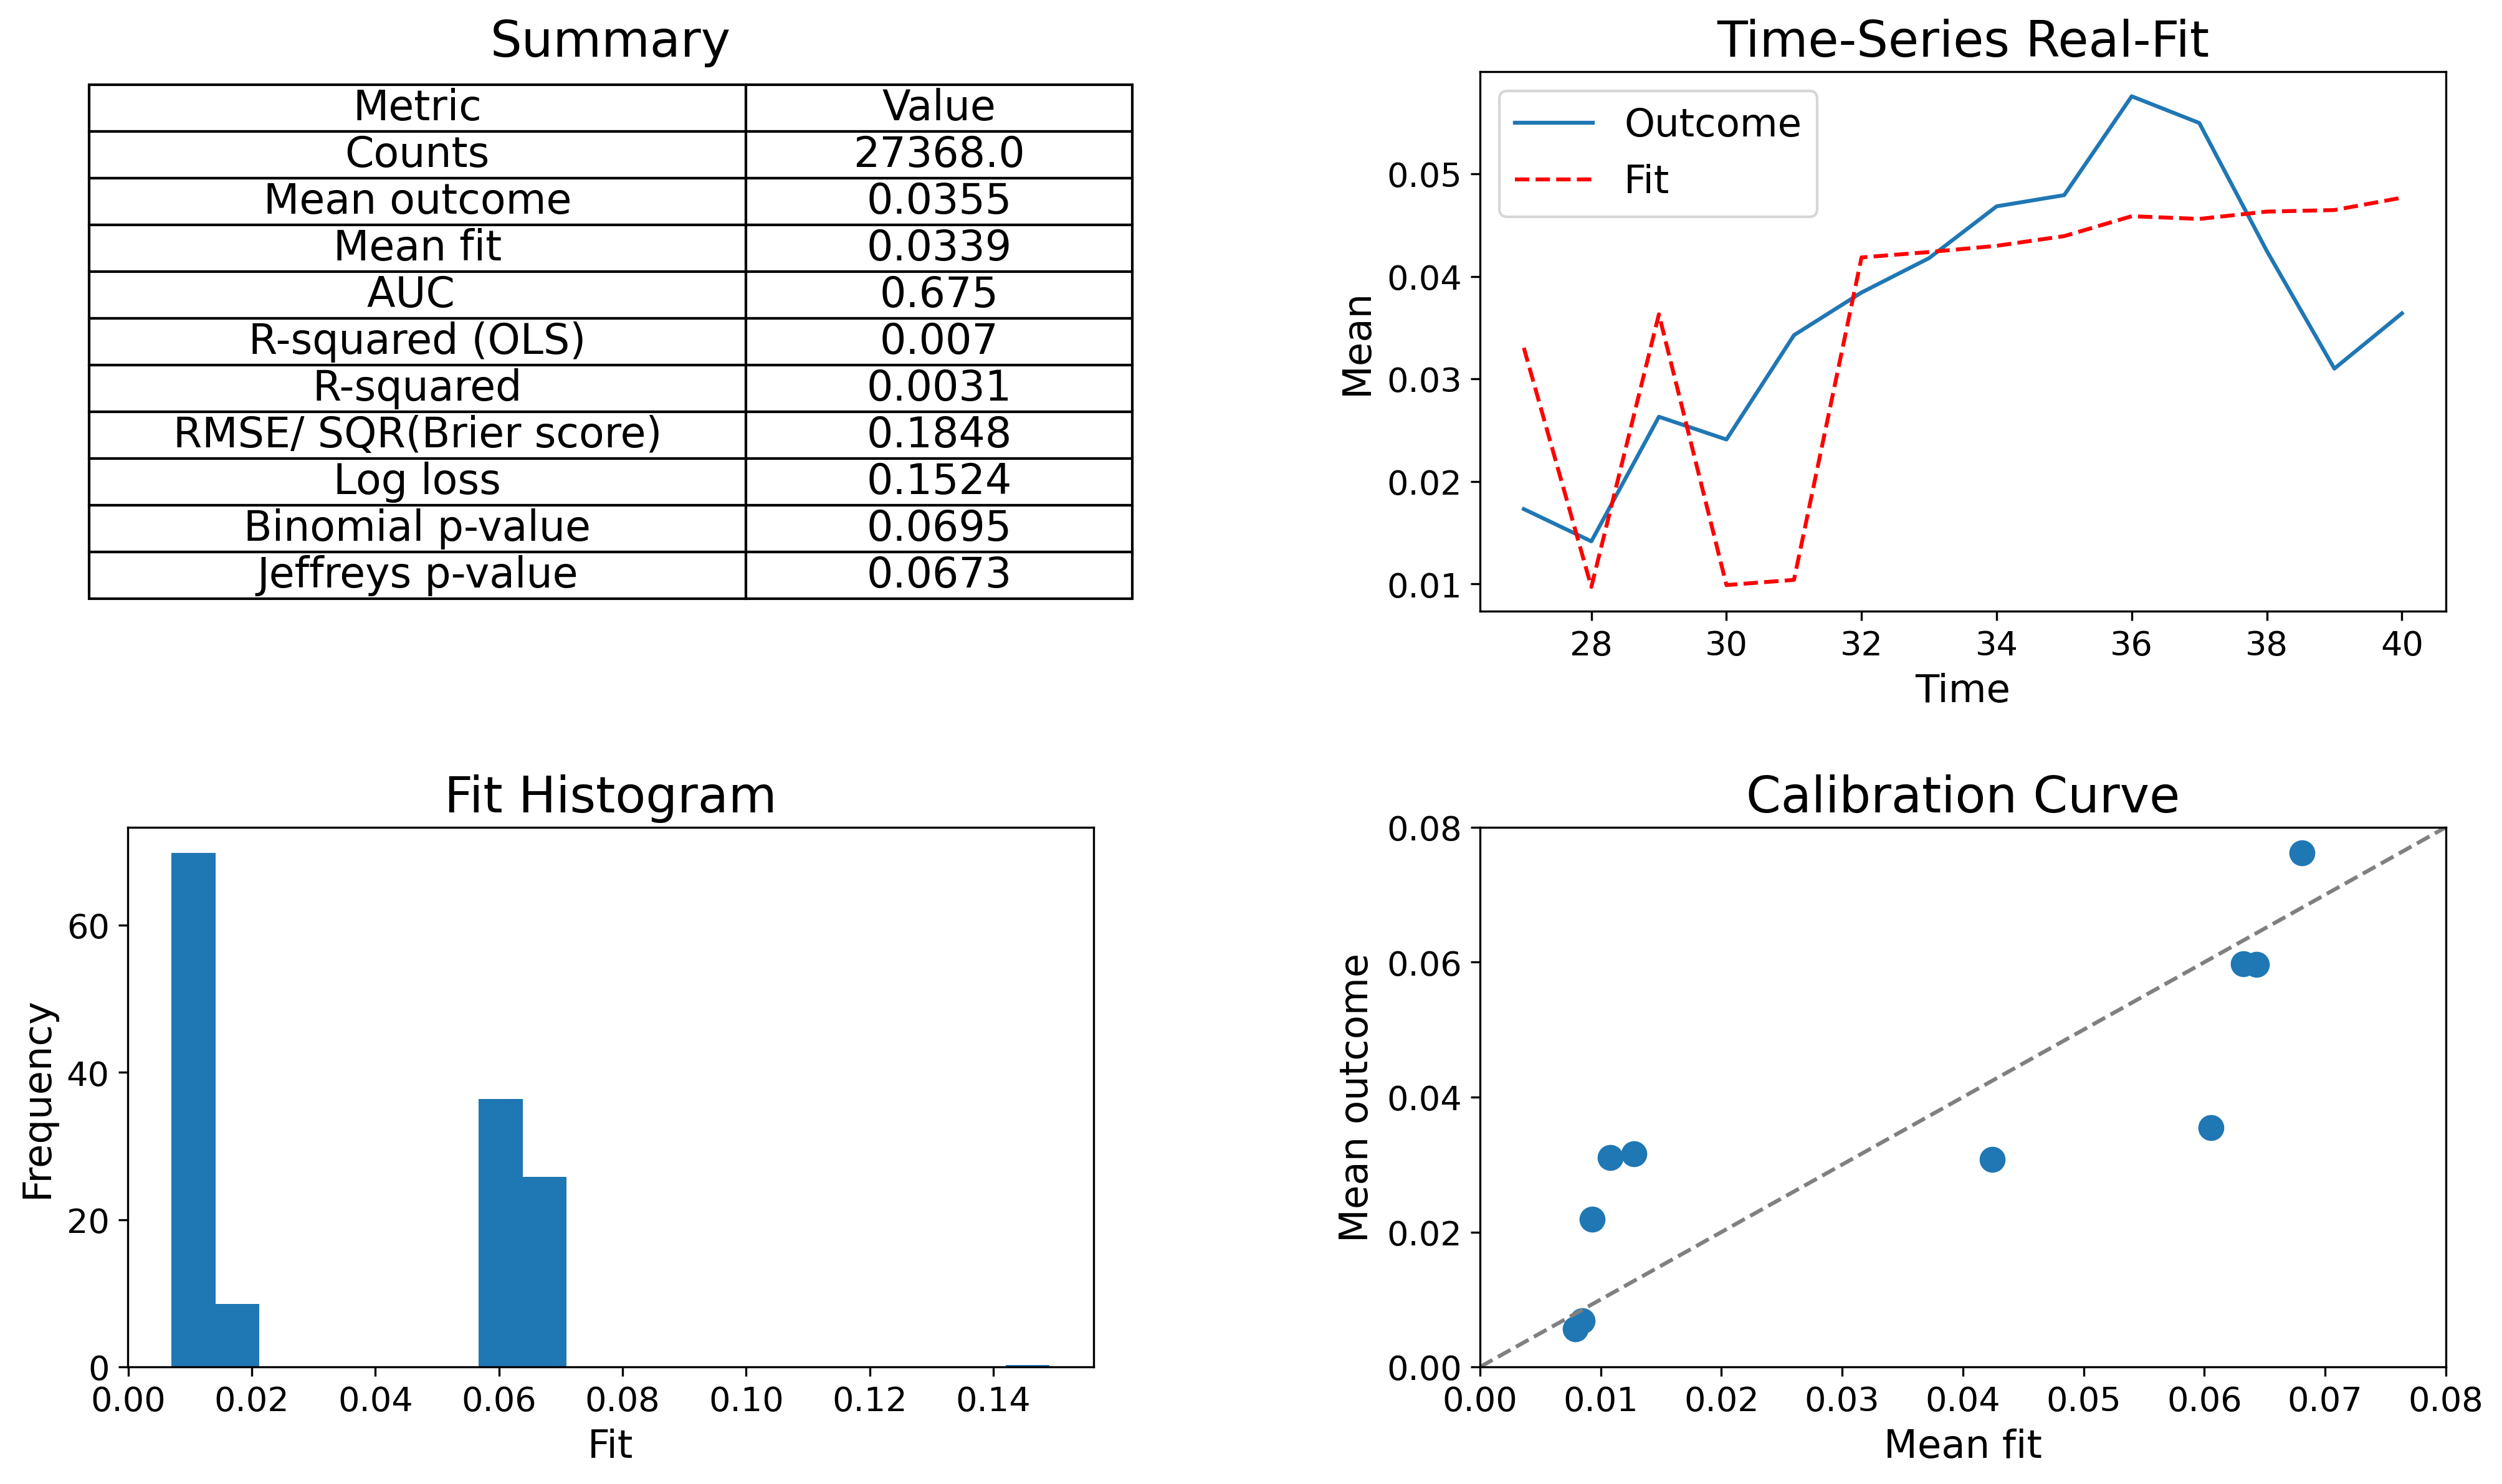

In [15]:
predictions_test = model_rfc_best.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_rf_best = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_rf_best = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [16]:
dt_boost = DecisionTreeClassifier(random_state=12345, max_depth=3, max_features =3)
model_dt_boost=AdaBoostClassifier(dt_boost, n_estimators=500, learning_rate=0.001) 
model_dt_boost.fit(X_train_scaled, y_train)
print(model_dt_boost.feature_importances_) 

[1.78718743e-01 8.15265136e-02 2.83282506e-01 3.07783527e-01
 4.55196470e-02 1.76735587e-02 2.60753674e-02 6.02304683e-03
 9.11547781e-03 4.40604597e-02 2.21153367e-04]


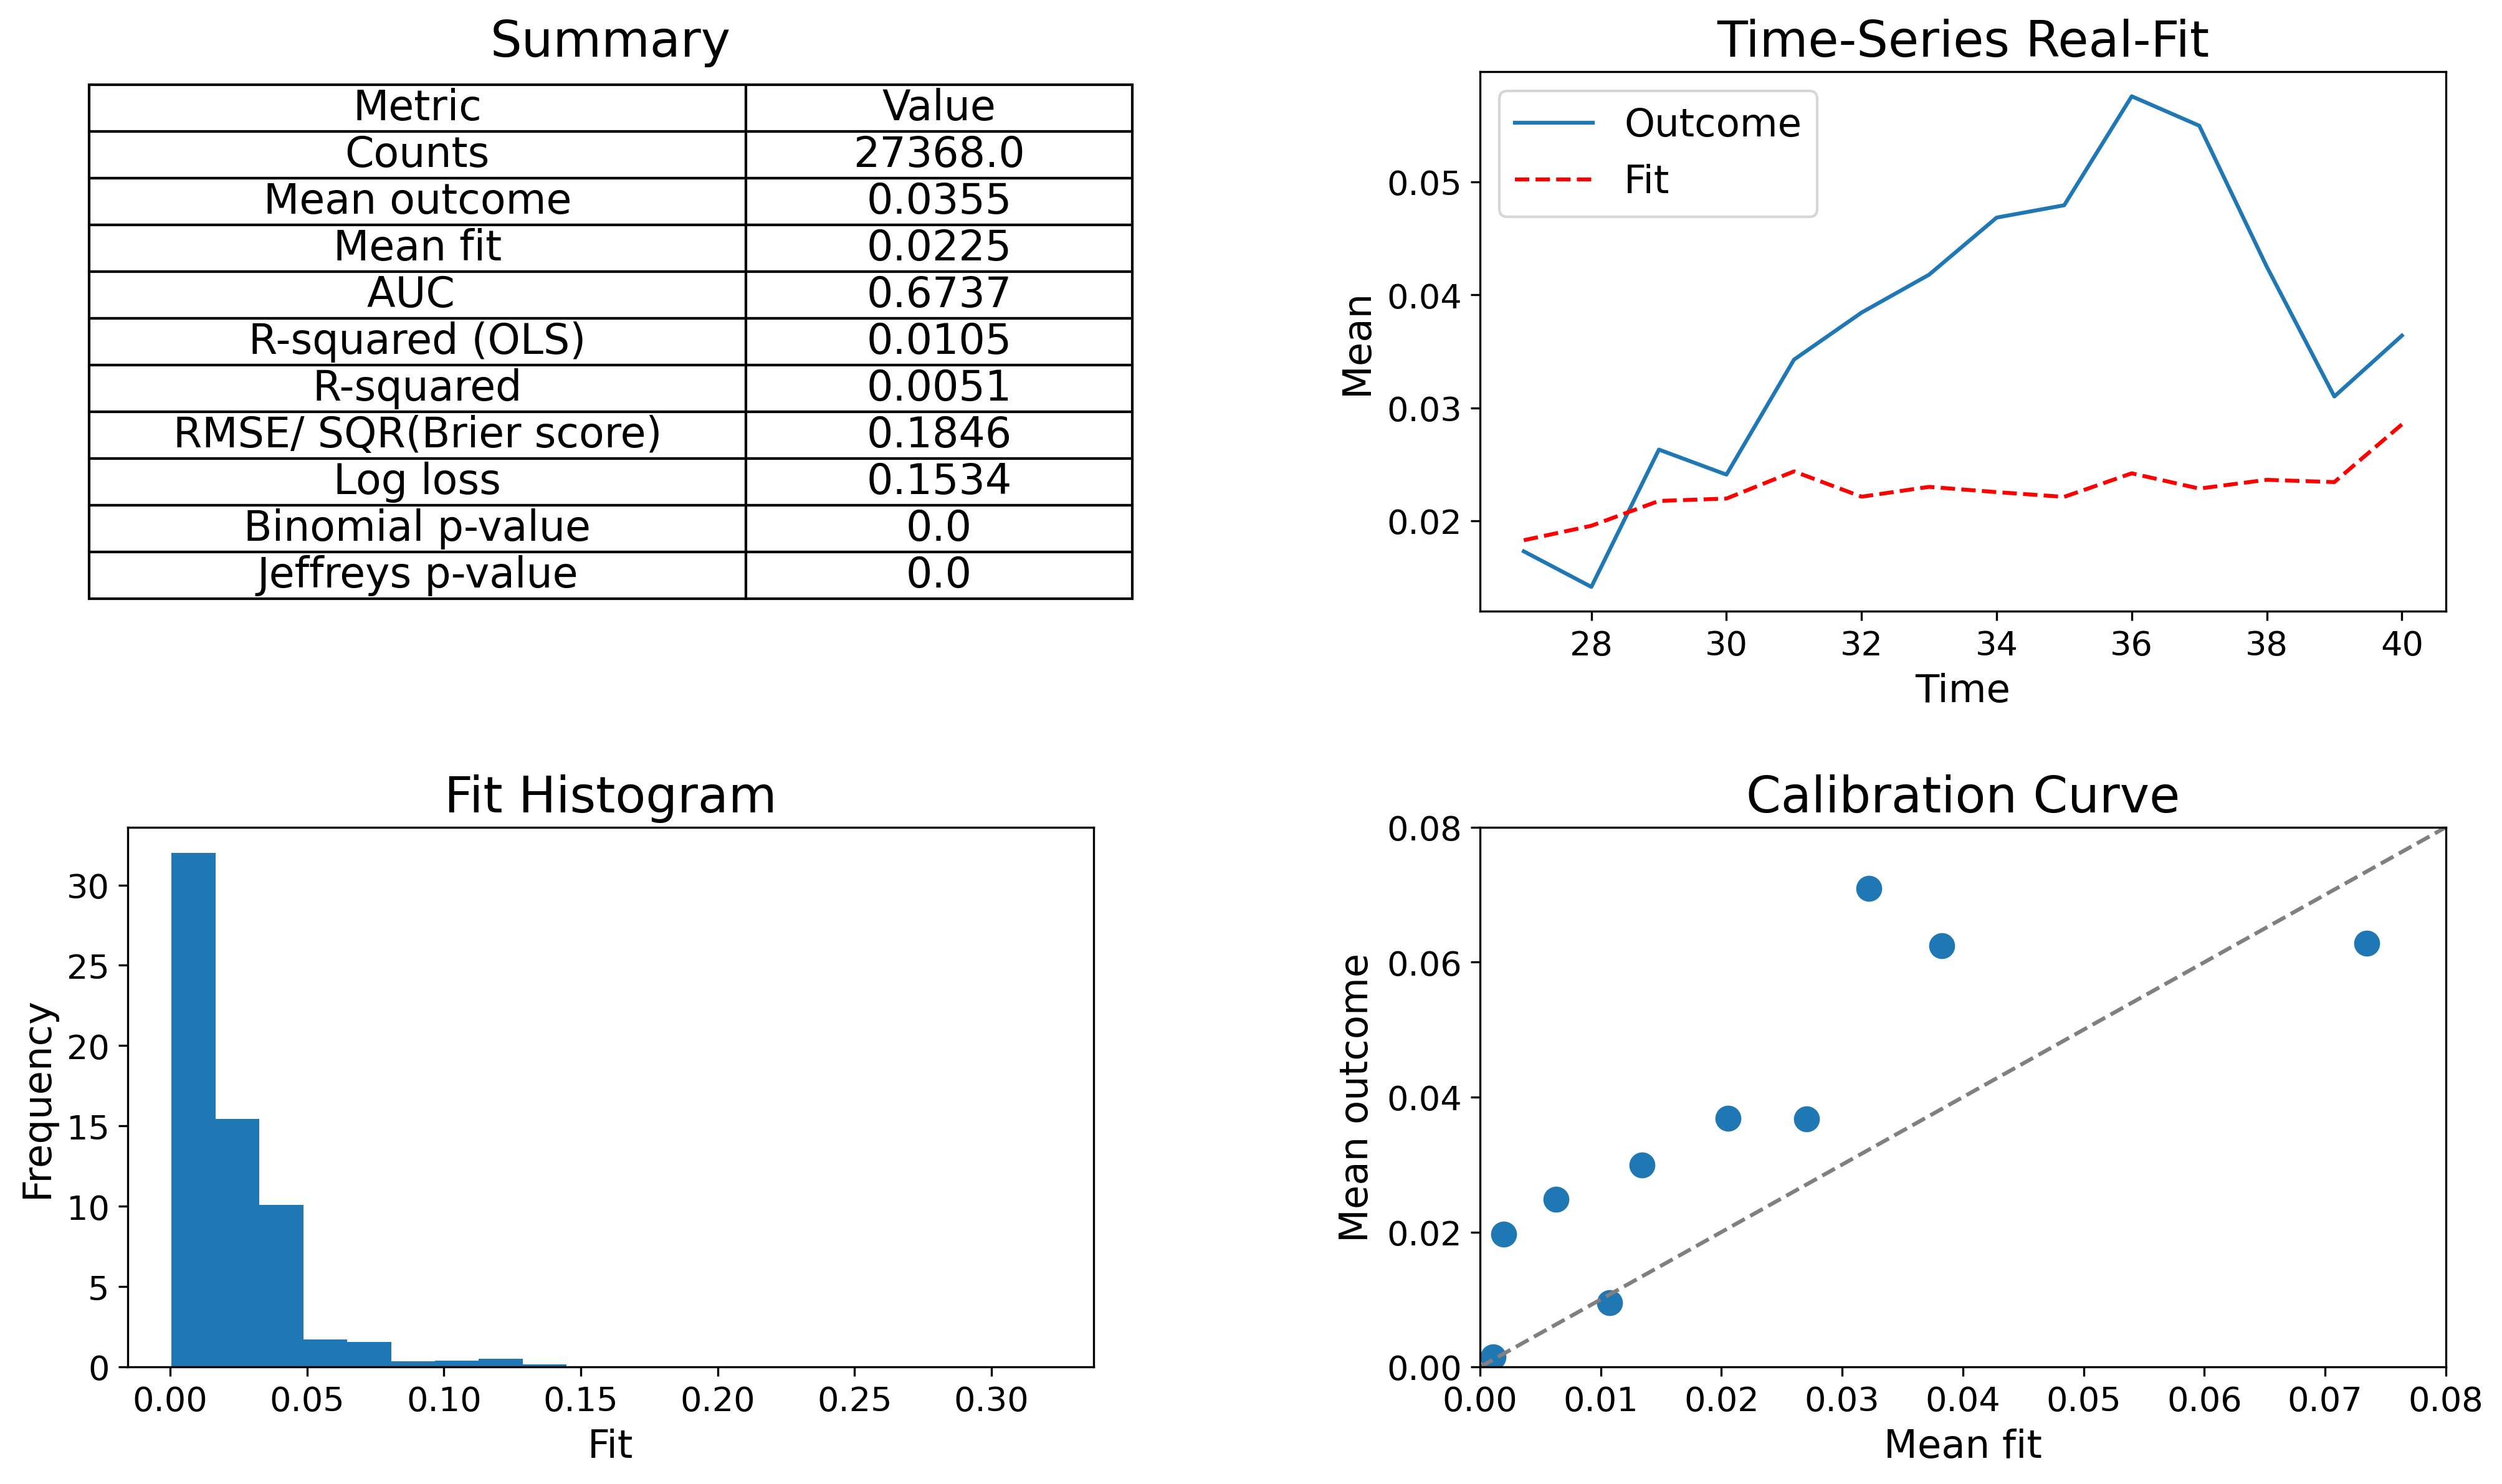

In [17]:
predictions_test = model_dt_boost.predict_proba(X_test_scaled)[:,1].T 
validation(predictions_test, y_test, data_test['time'].values) 
AUC_ada = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_ada = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [18]:
model_dt_grboost = GradientBoostingClassifier(learning_rate=0.01, n_estimators=100,  subsample=0.5, random_state=0, max_features=None, verbose  =0)  
model_dt_grboost.fit(X_train_scaled, y_train)  
print(model_dt_grboost.feature_importances_) 


[0.29721936 0.23027015 0.16473528 0.15514333 0.08152976 0.01273939
 0.00482663 0.00498533 0.02037036 0.02818041 0.        ]


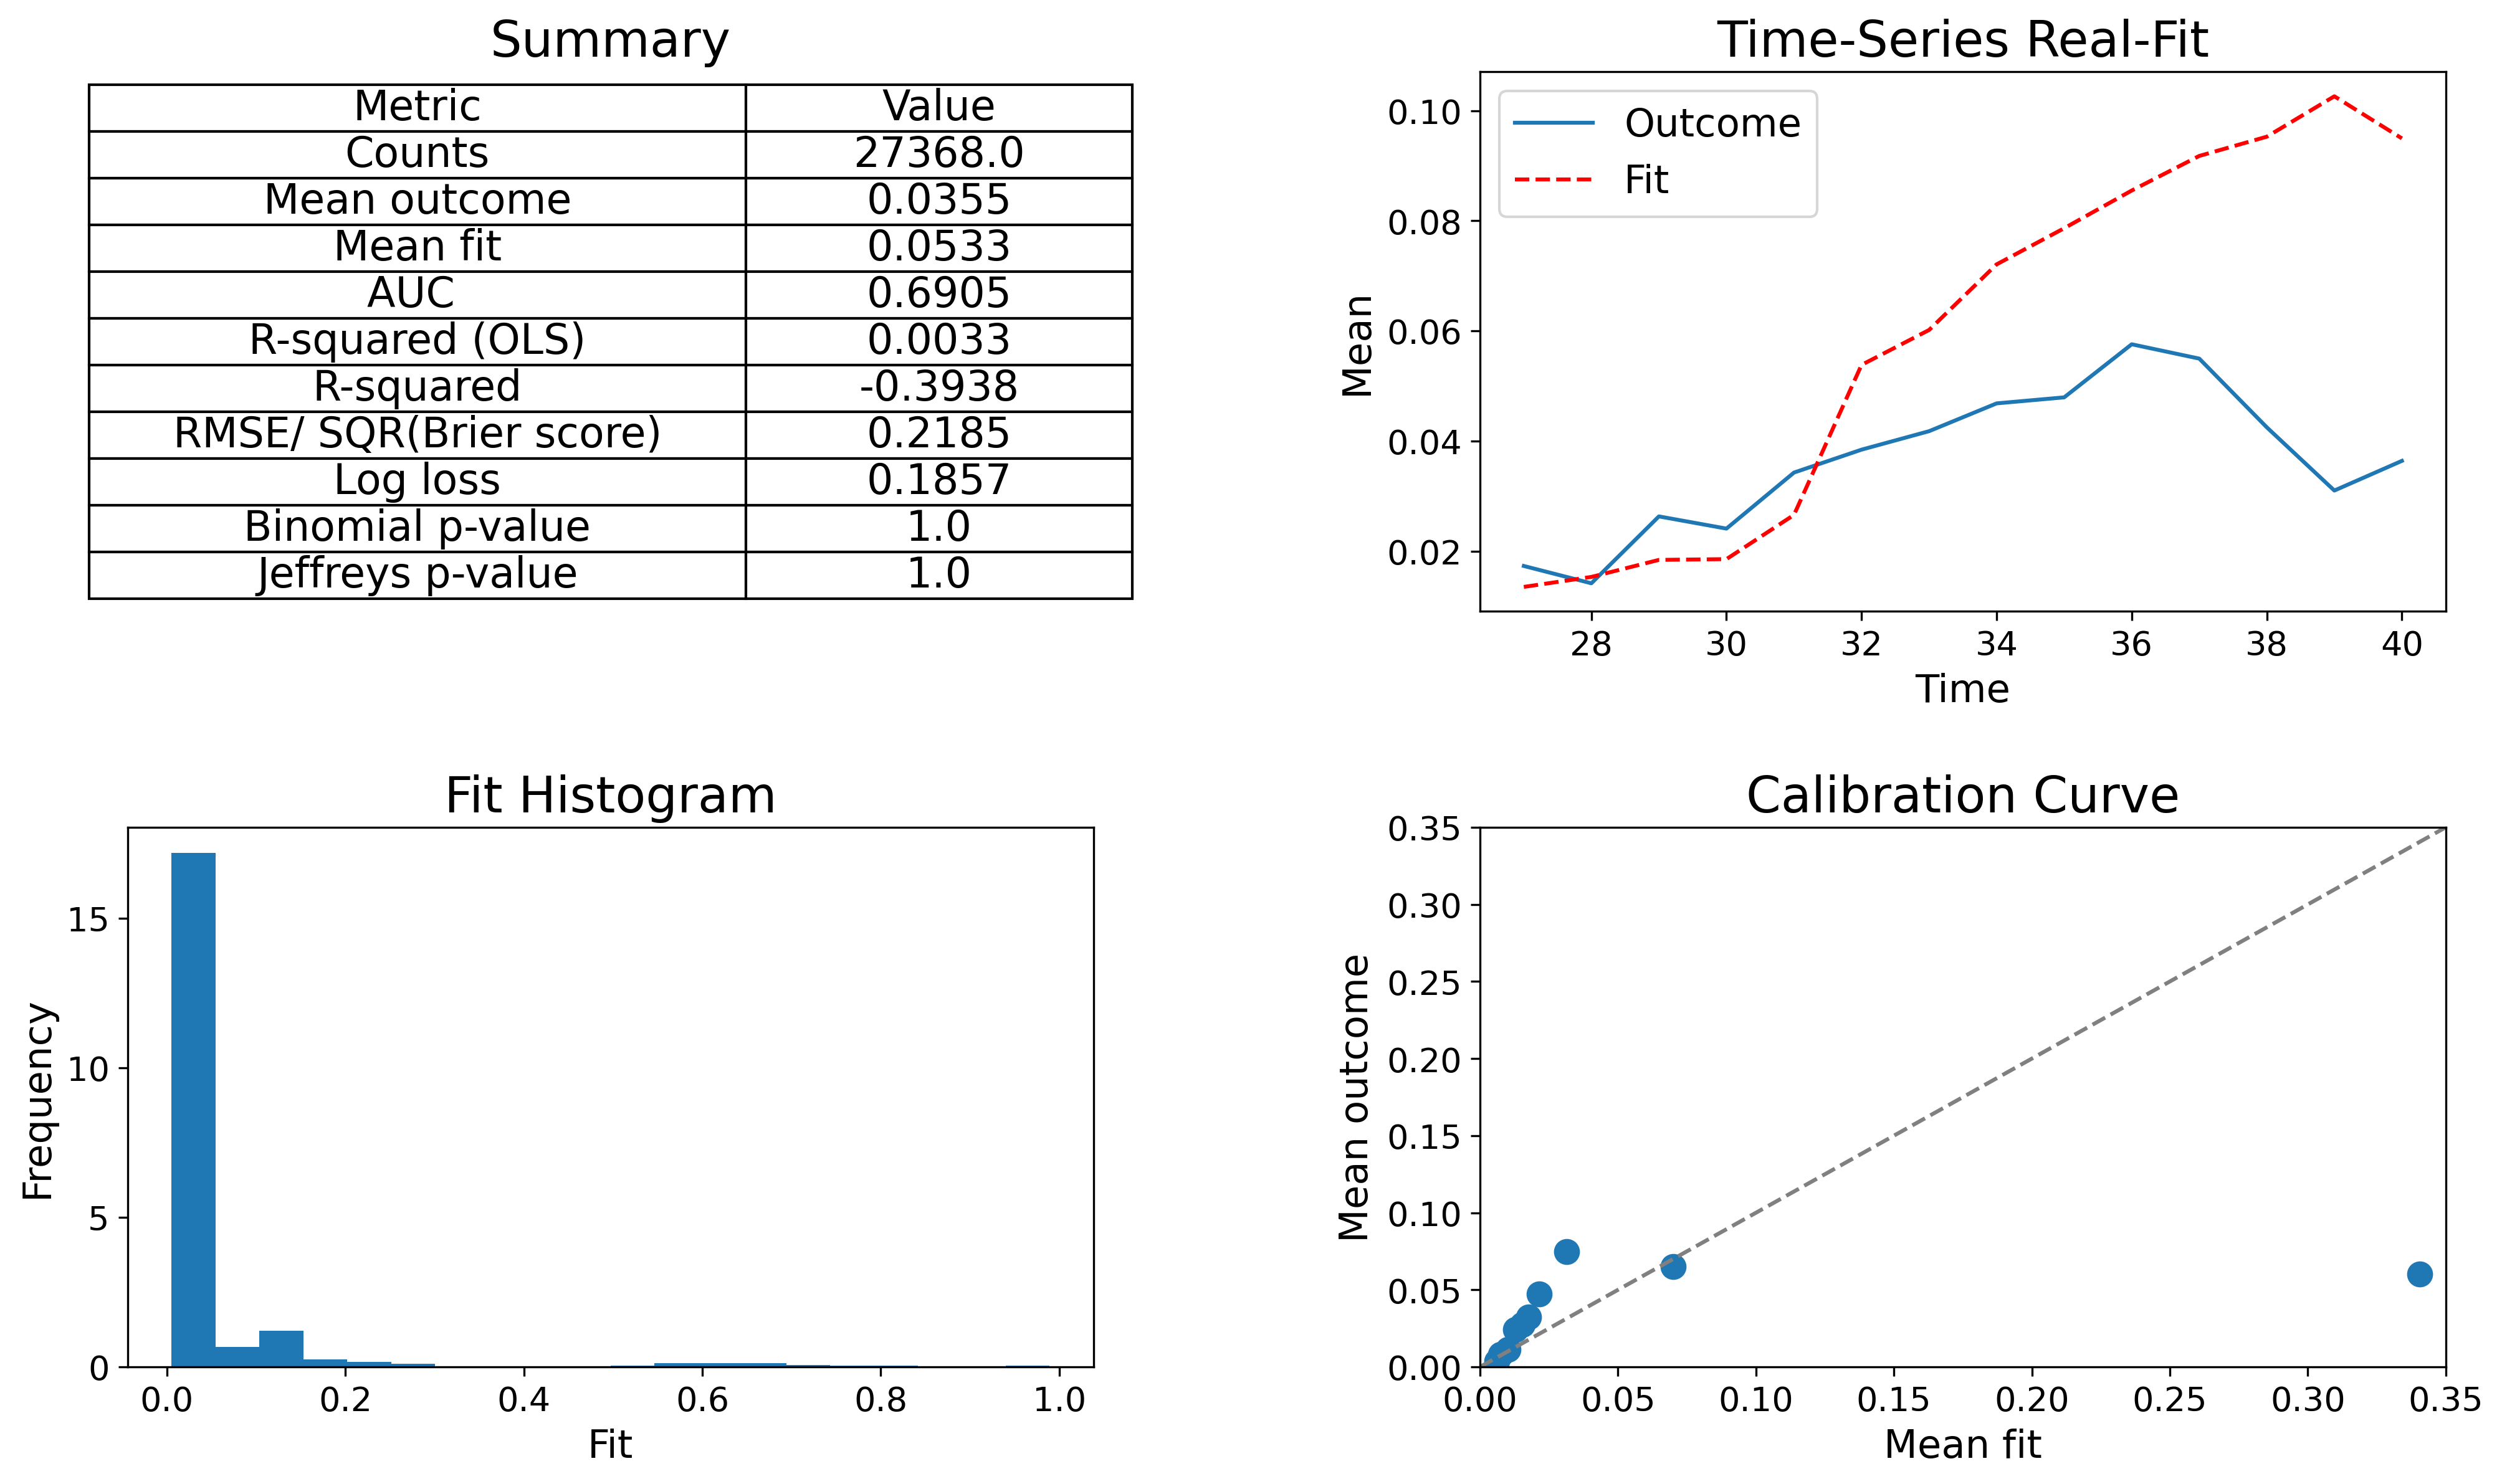

In [19]:
predictions_test = model_dt_grboost.predict_proba(X_test_scaled)[:,1].T 
validation(predictions_test, y_test, data_test['time'].values)  
AUC_sgb = roc_auc_score(y_test, predictions_test).round(4) 
sqrt_brier_sgb = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [20]:
model_lightgbm = LGBMClassifier(boosting_type='gbdt', num_leaves=31, max_depth=10,  learning_rate=0.1, n_estimators=100,  objective='binary', subsample=0.7, random_state=0,  n_jobs=2, silent=False) 
model_lightgbm.fit(X_train_scaled, y_train) 
print(model_lightgbm.feature_importances_) 

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 132, number of negative: 12570
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1172
[LightGBM] [Info] Number of data points in the train set: 12702, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010392 -> initscore=-4.556266
[LightGBM] [Info] Start training from score -4.556266
[664 579 549 605 146 105  80  86  82 104   0]


[LightGBM] [Warning] Unknown parameter: silent


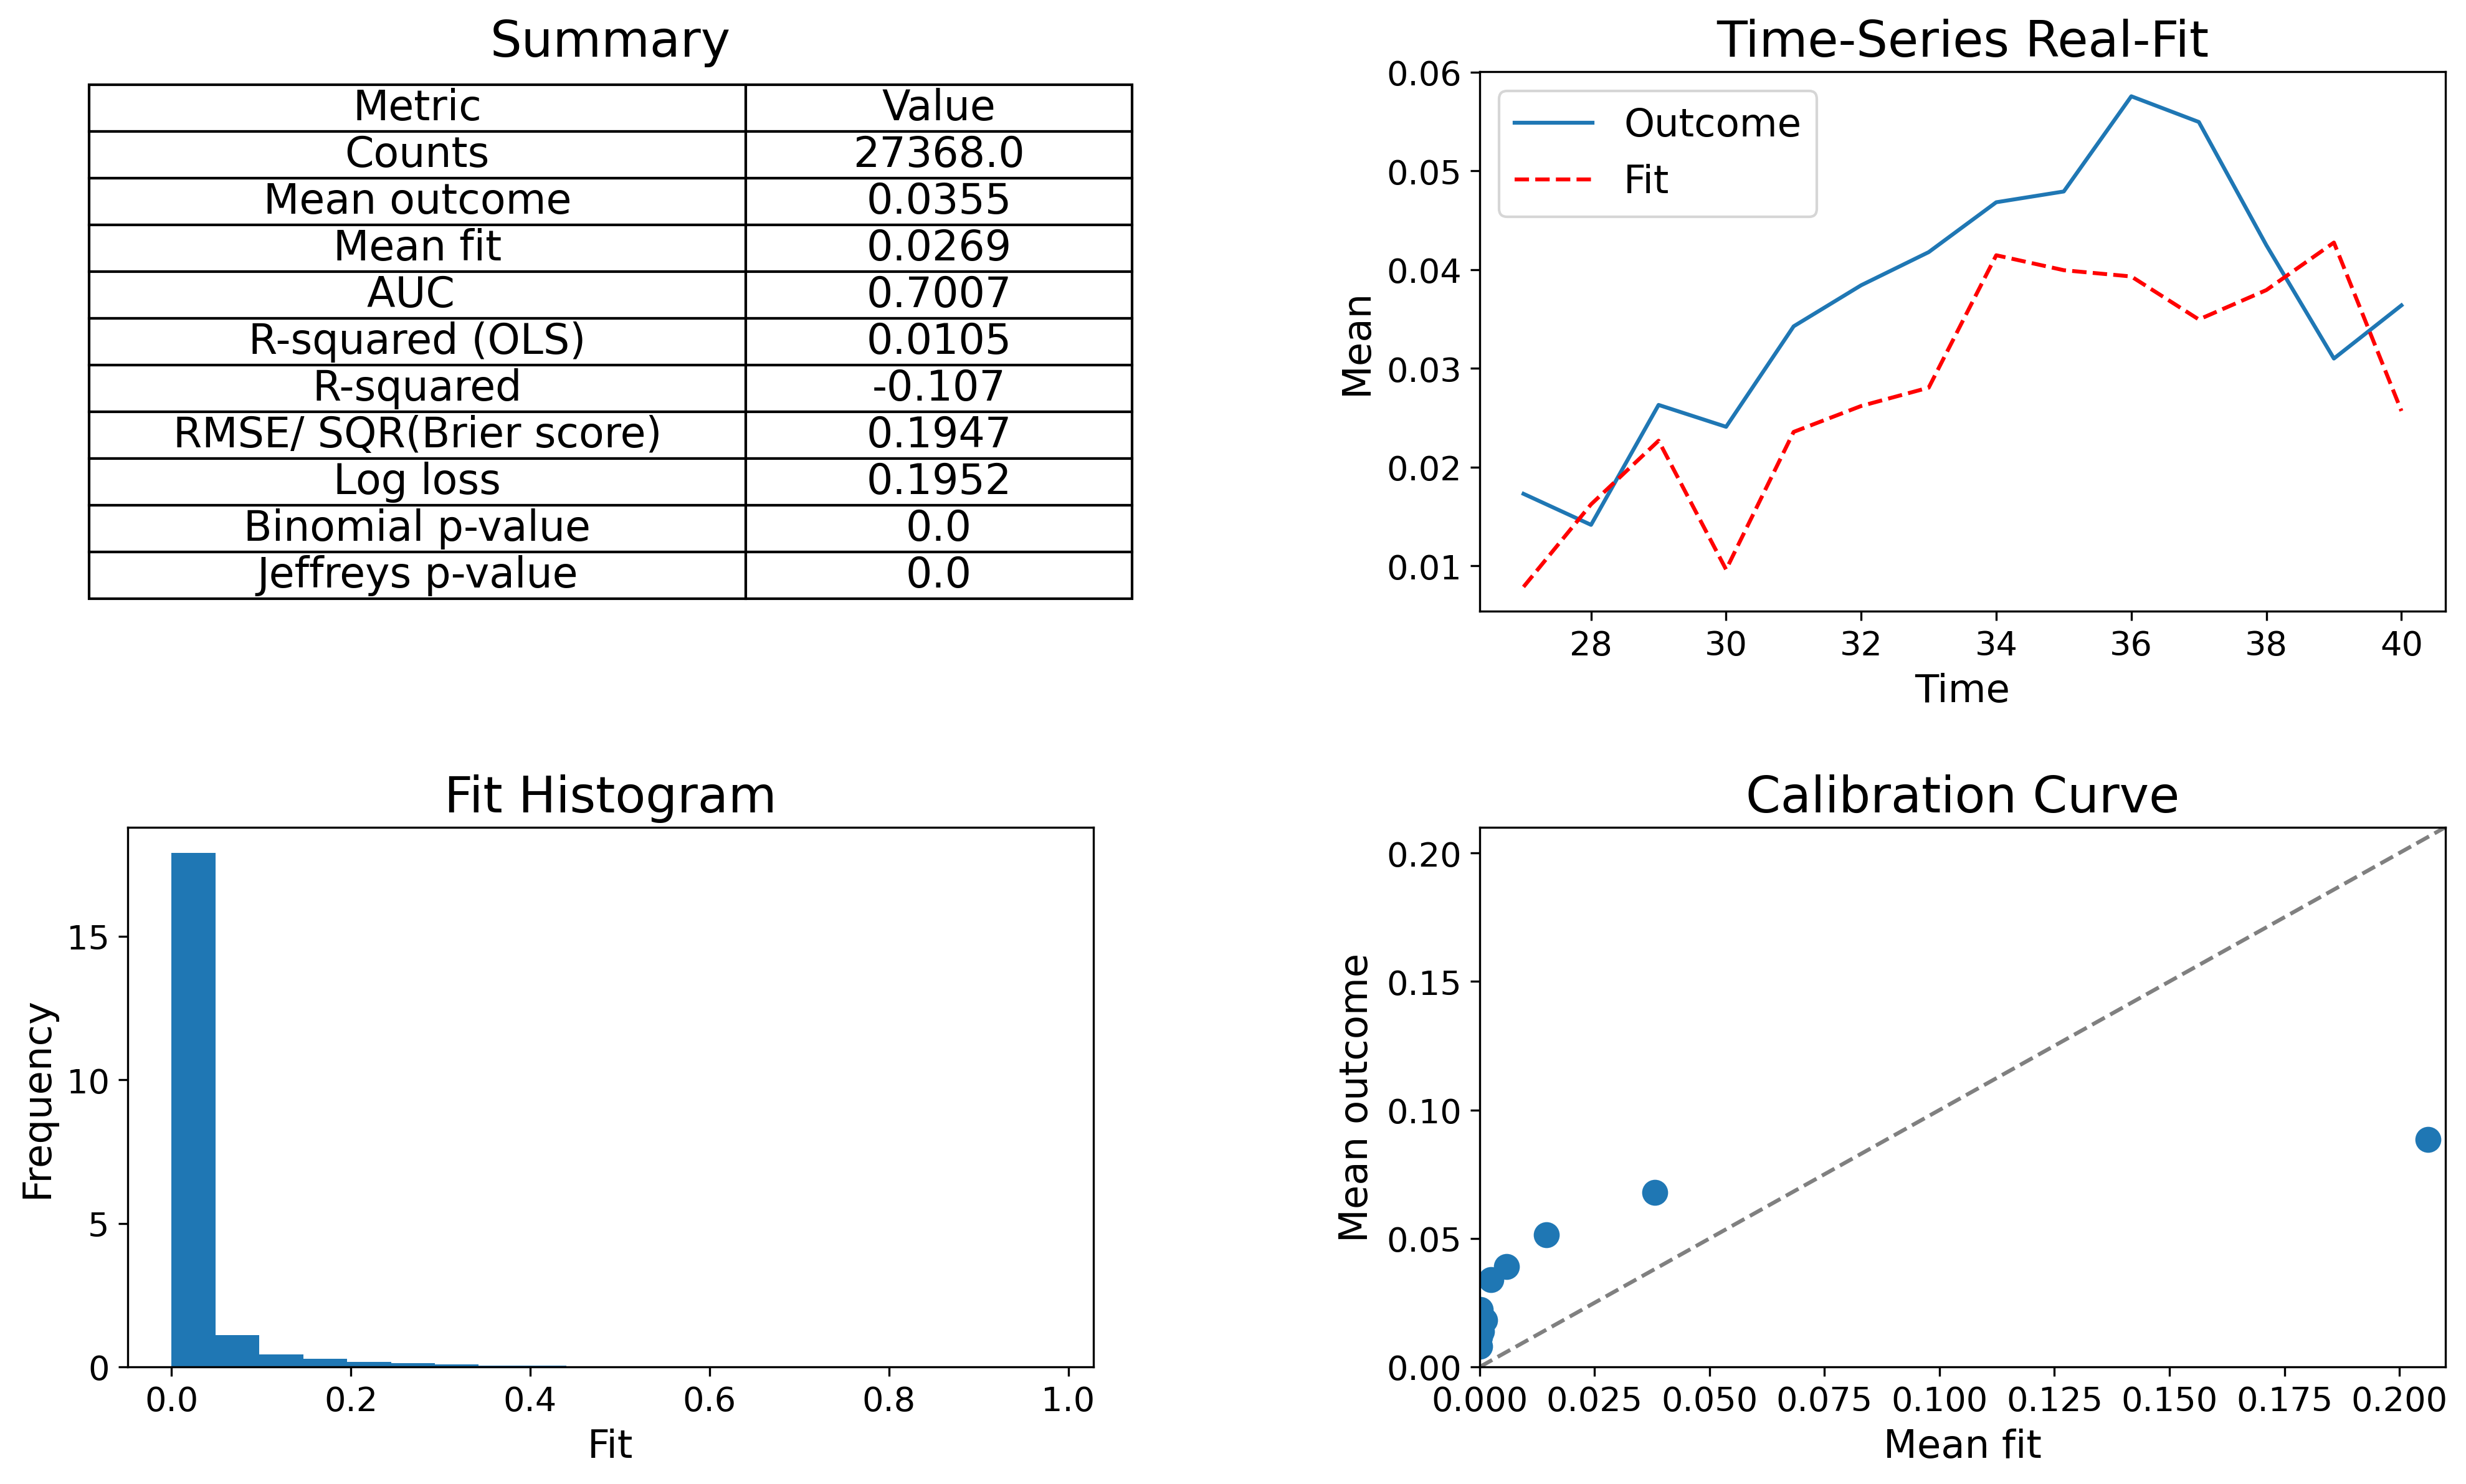

In [21]:
predictions_test = model_lightgbm.predict_proba(X_test_scaled)[:,1].T

validation(predictions_test, y_test, data_test['time'].values)
AUC_lgbm = roc_auc_score(y_test, predictions_test).round(4)
sqrt_brier_lgbm = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)

In [22]:
clf1 = LogisticRegression(penalty='none', fit_intercept=True, C=0.1, solver='saga', tol=1e-15, max_iter=10000)

clf2 = RandomForestClassifier(random_state=0, max_depth=5, warm_start=True, n_estimators=100)

clf3 = MLPClassifier(hidden_layer_sizes=(3,), random_state=2, max_iter=3000, warm_start=True,
                     activation='relu',
                     solver='sgd', learning_rate='adaptive', learning_rate_init=0.1,
                     validation_fraction=0.3,
                     verbose=False, n_iter_no_change=10, early_stopping=False, alpha=0.001,
                     shuffle=True)

In [23]:
vote_clf1 = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('nn', clf3)],
                             voting='soft')
vote_clf1 = vote_clf1.fit(X_train_scaled, y_train)

vote_clf2 = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2), ('nn', clf3)],
                             voting='soft', weights=[1,2,1],
                             flatten_transform=True)
vote_clf2 = vote_clf2.fit(X_train_scaled, y_train)

print(vote_clf2.transform(X_train_scaled).shape)

(12702, 6)


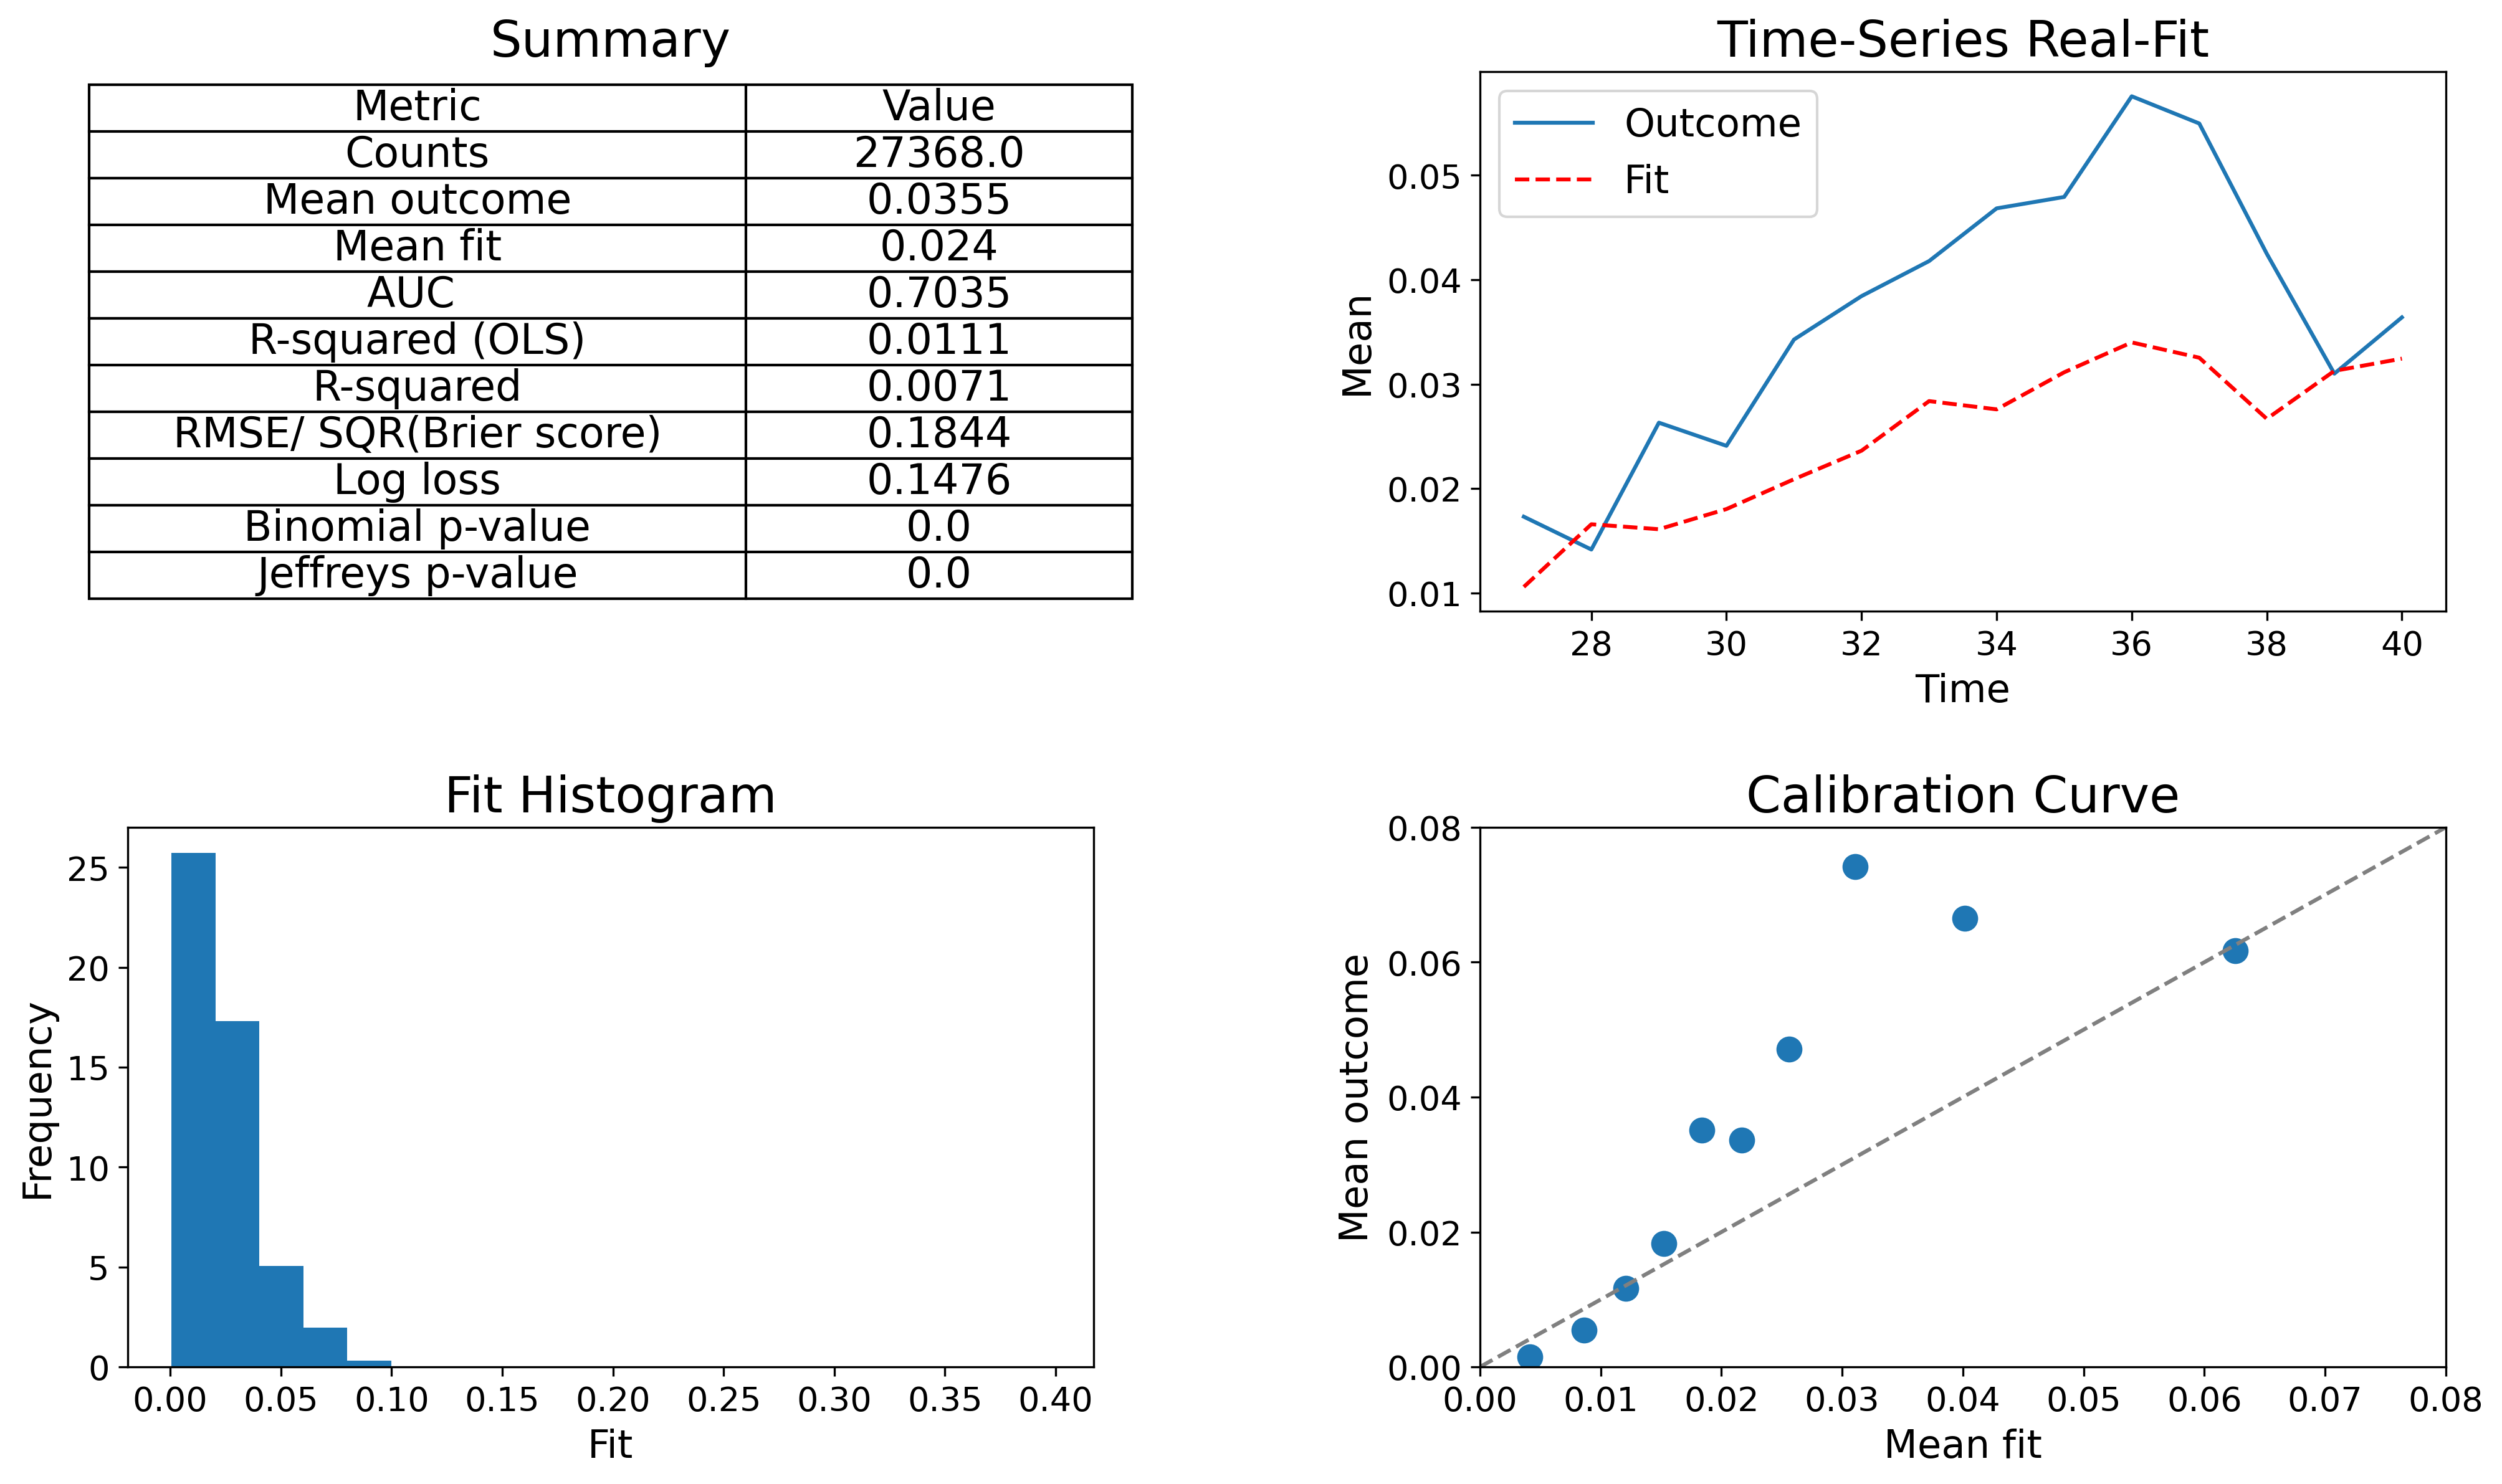

In [24]:
predictions_test = vote_clf1.predict_proba(X_test_scaled)[:,1].T

validation(predictions_test, y_test, data_test['time'].values)
AUC_vote = roc_auc_score(y_test, predictions_test).round(4)
sqrt_brier_vote = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)

In [25]:
result_table = pd.DataFrame([['Bagging (Logistic Regression)', AUC_bag, sqrt_brier_bag],
                             ['Boosting (Logistic Regression)', AUC_adareg, sqrt_brier_adareg],
                             ['Random Forest', AUC_rf, sqrt_brier_rf],
                             ['Random Forest (CV)', AUC_rf_best, sqrt_brier_rf_best],
                             ['Adaptive Boosted Trees', AUC_ada, sqrt_brier_ada],
                             ['Stochastic Gradient Boosting', AUC_sgb, sqrt_brier_sgb],
                             ['Light GBM', AUC_lgbm, sqrt_brier_lgbm],
                             ['Voting Classifier', AUC_vote, sqrt_brier_vote]
                            ]).rename(columns={0:'Method', 1:'AUC', 2:'RMSE SQR(Brier score)'})
pd.set_option('display.max_rows', None)
print(result_table.sort_values(by='AUC', axis=0, ascending=False))

                           Method     AUC  RMSE SQR(Brier score)
7               Voting Classifier  0.7035                 0.1844
6                       Light GBM  0.7007                 0.1947
5    Stochastic Gradient Boosting  0.6905                 0.2185
2                   Random Forest  0.6872                 0.1857
0   Bagging (Logistic Regression)  0.6842                 0.1862
3              Random Forest (CV)  0.6750                 0.1848
4          Adaptive Boosted Trees  0.6737                 0.1846
1  Boosting (Logistic Regression)  0.6613                 0.1854
